In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import os
print(os.listdir())

import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from keras.models import Sequential
from keras.layers import Dense

['env', 'heart disease2.ipynb', 'heart.csv', 'Heart_Disease.ipynb']



In [3]:
df = pd.read_csv("heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.shape

(1025, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

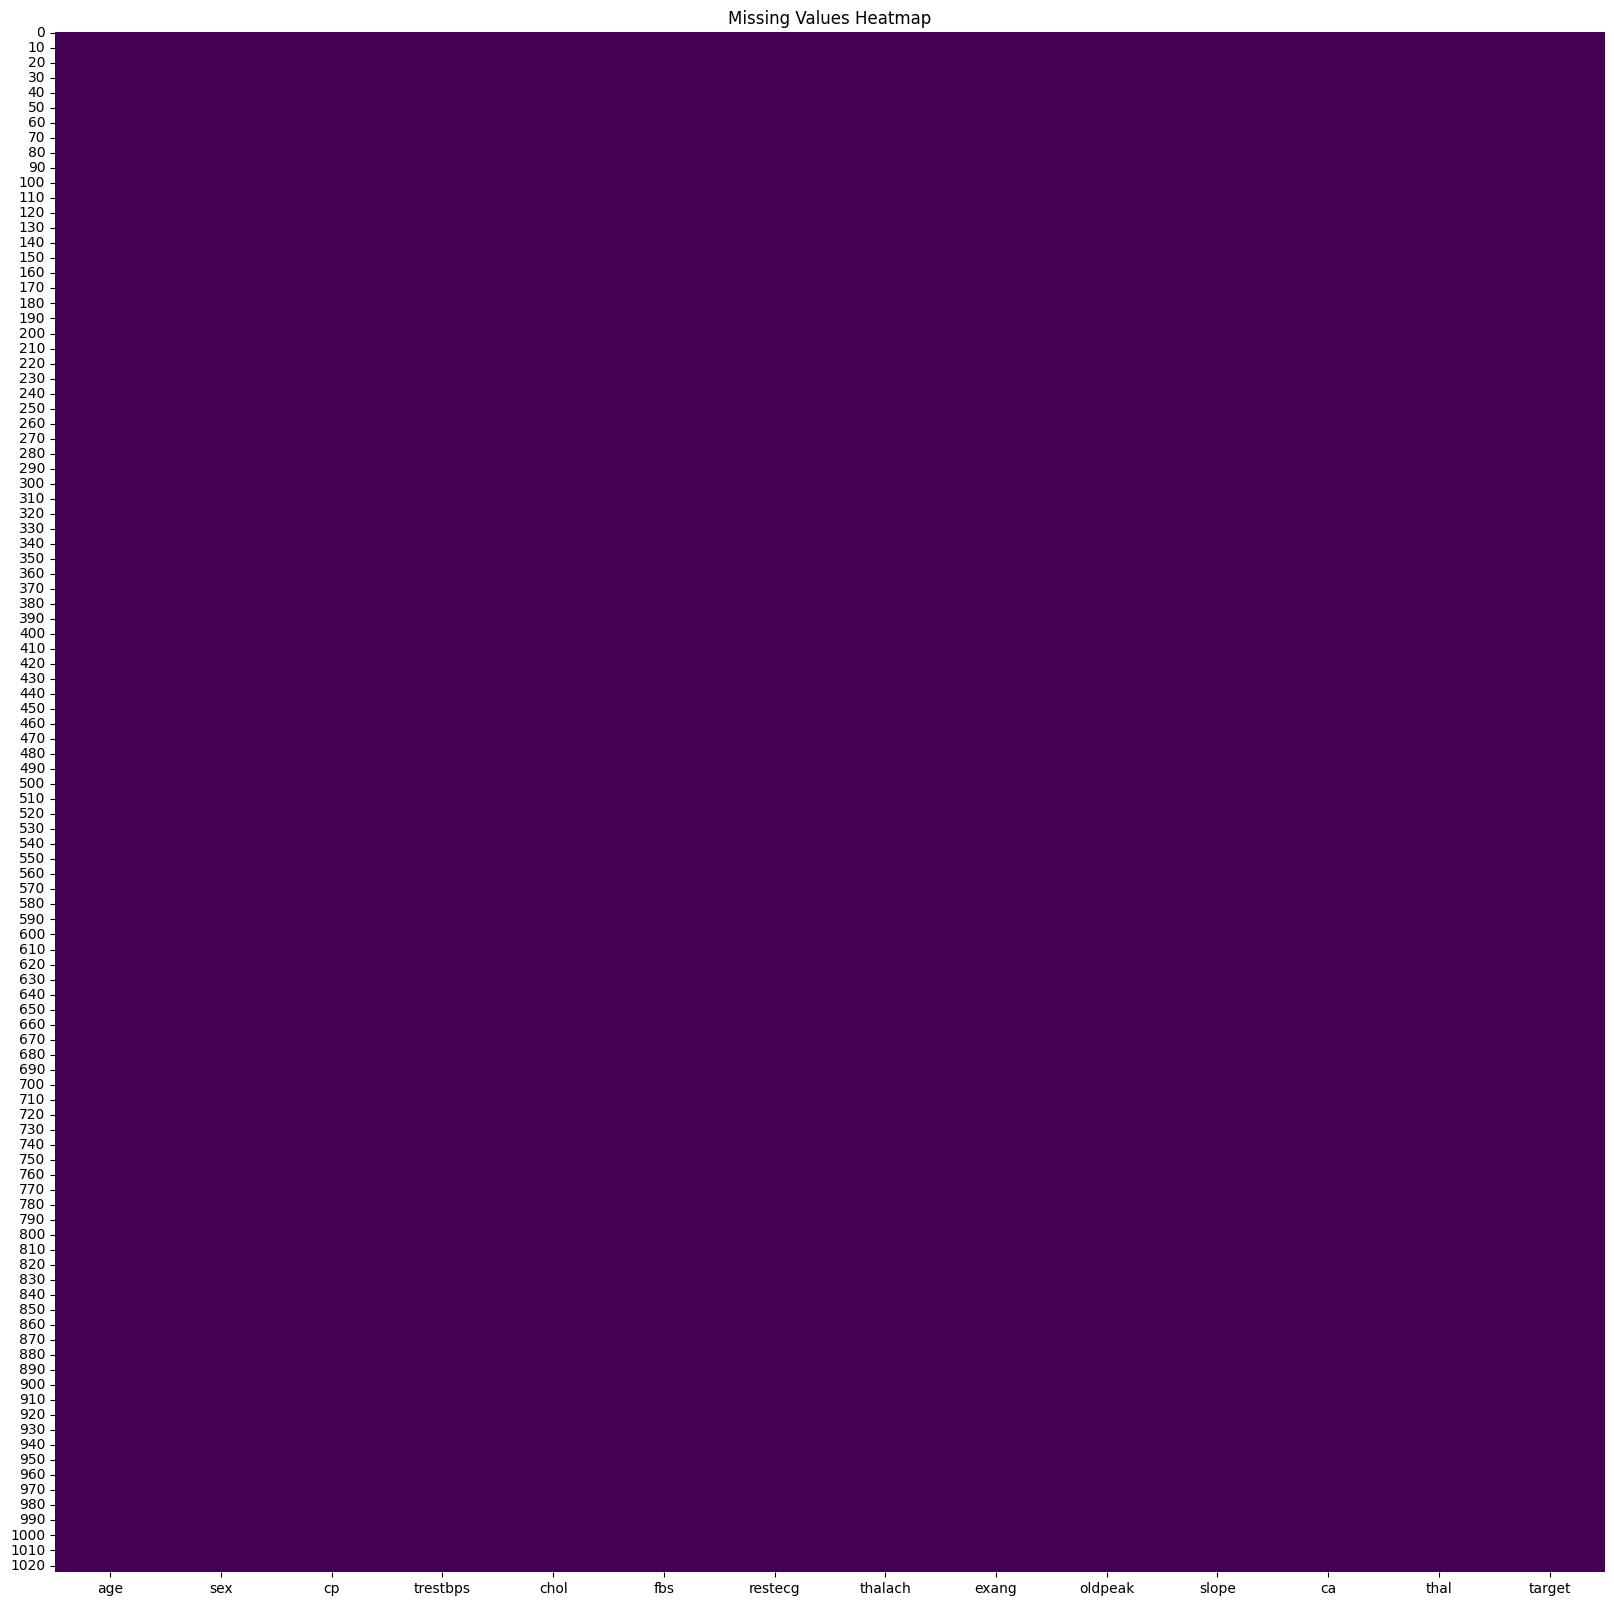

In [9]:
plt.figure(figsize=(20,20))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [10]:
df.duplicated().sum()

723

In [11]:
df = df.drop_duplicates()

In [12]:
print("Clean shape:", df.shape)

print(df['target'].value_counts())

Clean shape: (302, 14)
target
1    164
0    138
Name: count, dtype: int64


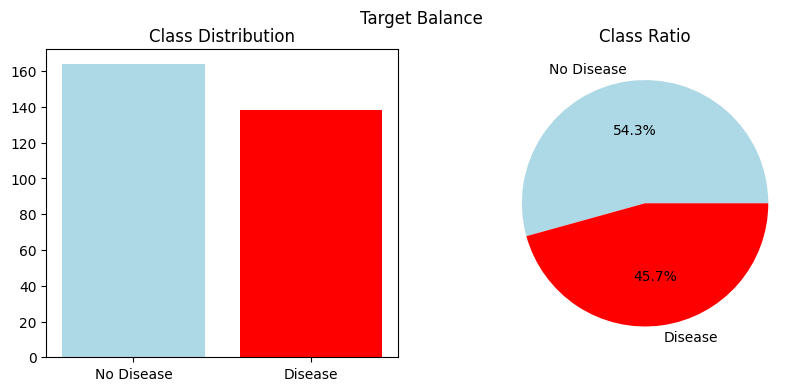

target
1    164
0    138
Name: count, dtype: int64
Imbalance ratio: 0.84


In [13]:
counts = df['target'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].bar(['No Disease', 'Disease'], counts, color=['lightblue','red'])
ax[0].set_title('Class Distribution')

ax[1].pie(counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%' ,colors=['lightblue','red'])
ax[1].set_title('Class Ratio')
plt.suptitle('Target Balance')
plt.show()
print(counts)
print(f"Imbalance ratio: {counts[0]/counts[1]:.2f}")

In [14]:
continuous=['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print(f"Continuous: {continuous}")
print(f"Categorical: {categorical}")
print("Target: target")

Continuous: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Target: target


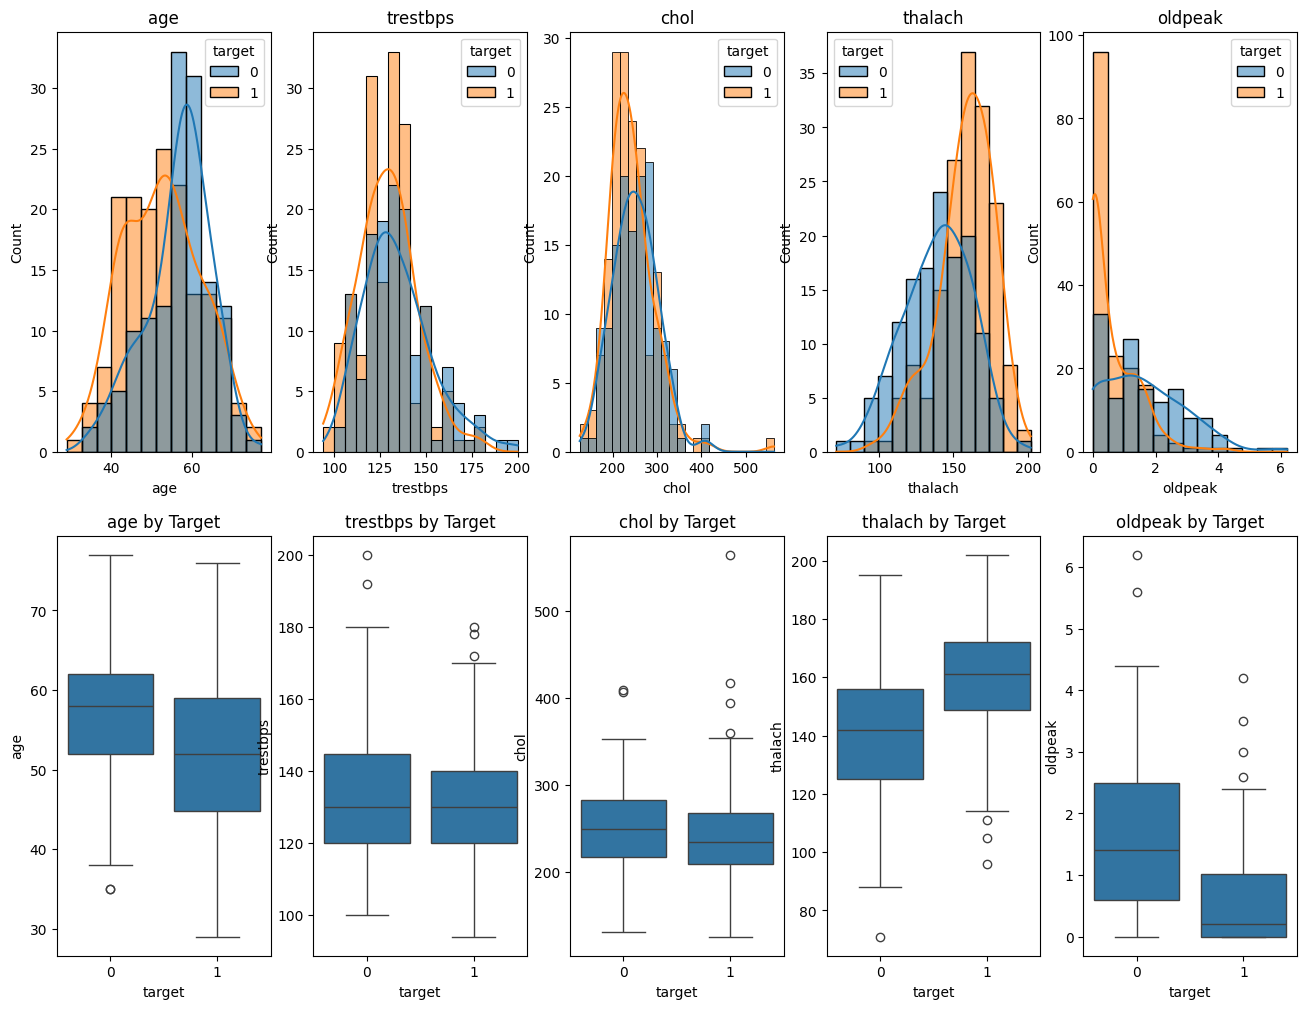

In [15]:
fig, ax = plt.subplots(2, len(continuous), figsize=(16,12))
for i, col in enumerate(continuous):
    
    sns.histplot(df, x=col, hue='target', kde=True, ax=ax[0,i])
    ax[0,i].set_title(col)
    
    sns.boxplot(x='target', y=col, data=df, ax=ax[1,i])
    ax[1,i].set_title(f'{col} by Target')

In [16]:
mean_values_by_target =df.groupby('target')[continuous].mean().reset_index().T
mean_values_by_target

,0,1
target,0.000000,1.000000
age,56.601449,52.585366
trestbps,134.398551,129.250000
chol,251.086957,242.640244
thalach,139.101449,158.378049
oldpeak,1.585507,0.586585


In [17]:
median_values_by_target =df.groupby('target')[continuous].median().reset_index().T
median_values_by_target

,0,1
target,0.0,1.0
age,58.0,52.0
trestbps,130.0,130.0
chol,249.0,234.5
thalach,142.0,161.0
oldpeak,1.4,0.2


In [18]:
df.agg(['mean' , 'median']).T

,mean,median
age,54.420530,55.5
sex,0.682119,1.0
cp,0.963576,1.0
trestbps,131.602649,130.0
chol,246.500000,240.5
fbs,0.149007,0.0
restecg,0.526490,1.0
thalach,149.569536,152.5
exang,0.327815,0.0
oldpeak,1.043046,0.8


In [19]:
for col in continuous:
    IQR = df[col].quantile(0.75) - df[col].quantile(0.25)
    outliers = df[(df[col] < df[col].quantile(0.25) - 1.5*IQR) |
                  (df[col] > df[col].quantile(0.75) + 1.5*IQR)]
    
    print(f"{col}: {len(outliers)}")

age: 0
trestbps: 9
chol: 5
thalach: 1
oldpeak: 5


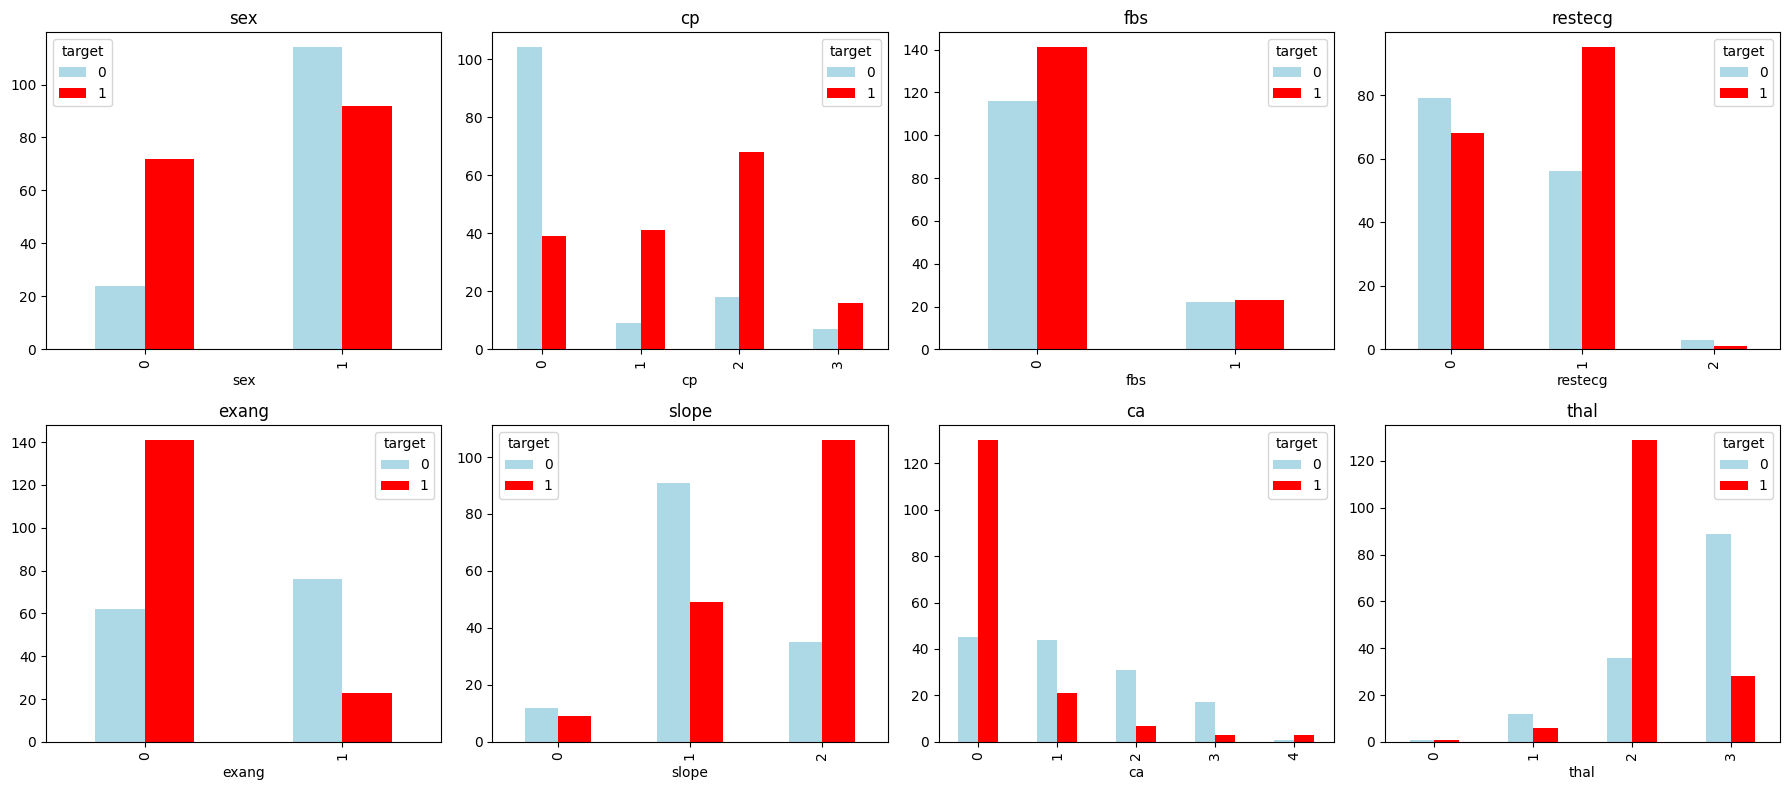

In [20]:
fig, ax = plt.subplots(2, 4, figsize=(18,8))
ax = ax.flatten()

for i, col in enumerate(categorical):
    df.groupby([col, 'target']).size().unstack().plot(kind='bar', ax=ax[i] , color=['lightblue','red'])
    ax[i].set_title(col)


plt.tight_layout()
plt.show()

In [21]:
print("=== Disease Rate % per Category ===\n")

for col in categorical:
    print(col)
    print(df.groupby(col)['target'].mean()*100)

=== Disease Rate % per Category ===

sex
sex
0    75.000000
1    44.660194
Name: target, dtype: float64
cp
cp
0    27.272727
1    82.000000
2    79.069767
3    69.565217
Name: target, dtype: float64
fbs
fbs
0    54.863813
1    51.111111
Name: target, dtype: float64
restecg
restecg
0    46.258503
1    62.913907
2    25.000000
Name: target, dtype: float64
exang
exang
0    69.458128
1    23.232323
Name: target, dtype: float64
slope
slope
0    42.857143
1    35.000000
2    75.177305
Name: target, dtype: float64
ca
ca
0    74.285714
1    32.307692
2    18.421053
3    15.000000
4    75.000000
Name: target, dtype: float64
thal
thal
0    50.000000
1    33.333333
2    78.181818
3    23.931624
Name: target, dtype: float64


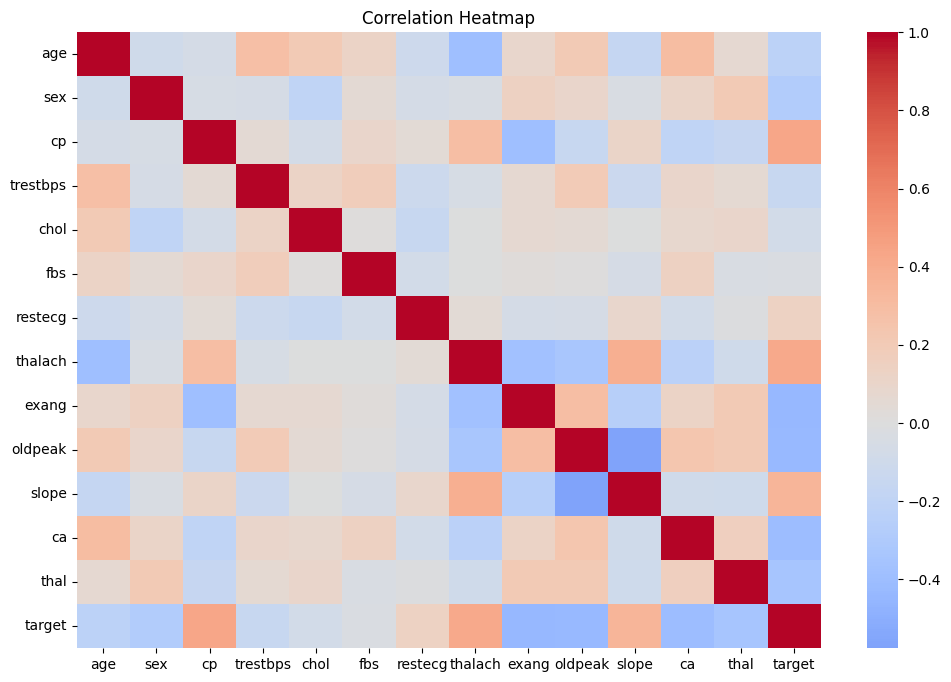


Top features correlated with target:

cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


In [22]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

print("\nTop features correlated with target:\n")
print(corr['target'].drop('target').sort_values(ascending=False))

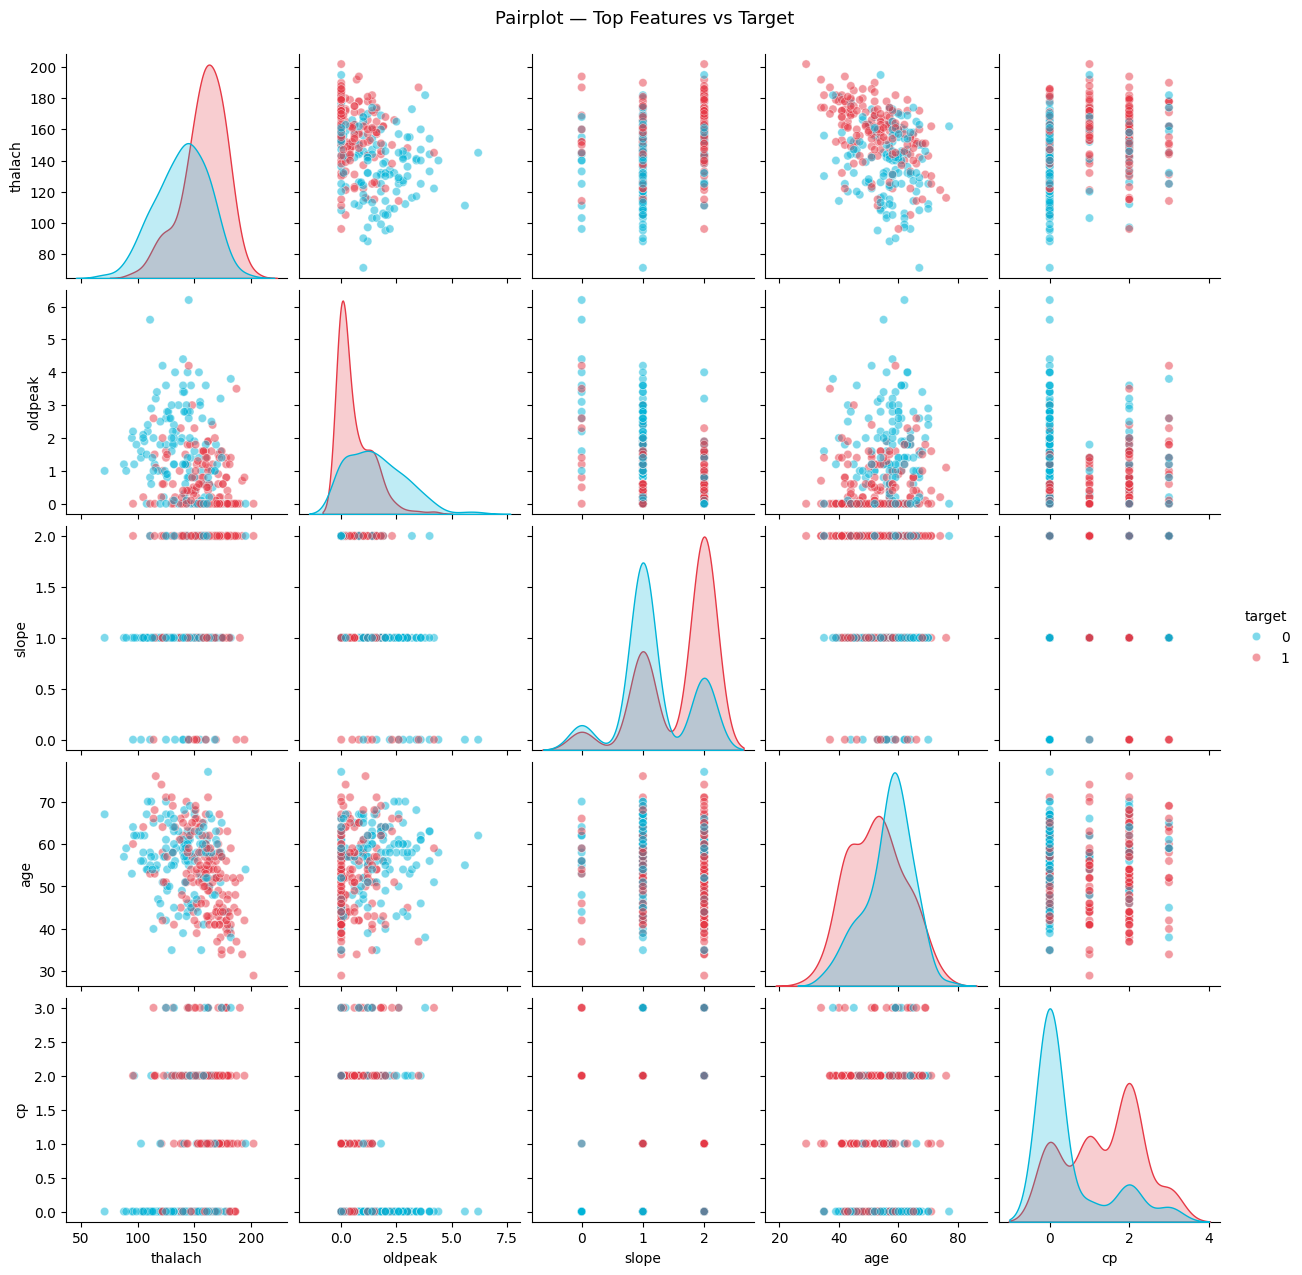

In [23]:
top_features = ['thalach', 'oldpeak',"slope", 'age', 'cp', 'target']

sns.pairplot(df[top_features], hue='target',
             palette={0: '#00b4d8', 1: '#e63946'},
             diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Pairplot — Top Features vs Target', y=1.02, fontsize=13)
plt.show()

In [24]:
from scipy.stats import ttest_ind

for col in continuous:
    group0 = df[df['target'] == 0][col]
    group1 = df[df['target'] == 1][col]
    
    stat, p = ttest_ind(group0, group1)
    print(f"{col}: t-stat={stat:.2f}, p-value={p:.4f}")

age: t-stat=3.93, p-value=0.0001
trestbps: t-stat=2.56, p-value=0.0109
chol: t-stat=1.42, p-value=0.1580
thalach: t-stat=-8.01, p-value=0.0000
oldpeak: t-stat=8.23, p-value=0.0000


In [25]:
from scipy.stats import chi2_contingency
print(f"{'Feature':<12} {'Chi2':>10} {'p-value':>12} {'Significant':>12}")
for col in categorical:
    contingency_table = pd.crosstab(df[col], df['target'])
    stat, p, dof, expected = chi2_contingency(contingency_table)
    significant = 'Yes' if p < 0.05 else 'No'
    print(f"{col:<12} {stat:>10.2f} {p:>12.4f} {significant:>12}")

Feature            Chi2      p-value  Significant
sex               23.08       0.0000          Yes
cp                80.98       0.0000          Yes
fbs                0.09       0.7611           No
restecg            9.73       0.0077          Yes
exang             55.46       0.0000          Yes
slope             46.89       0.0000          Yes
ca                73.69       0.0000          Yes
thal              84.61       0.0000          Yes


In [26]:
df_features=df.copy()

In [27]:
# thalach → low max heart rate = high risk
df_features['low_thalach'] = (df_features['thalach'] < 140).astype(int)

# oldpeak → ST depression > 2 = ischemia
df_features['high_oldpeak'] = (df_features['oldpeak'] > 2).astype(int)

# age → risk increases after 55
df_features['age_group'] = pd.cut(df_features['age'],
                                   bins=[0, 40, 55, 70, 100],
                                   labels=[0, 1, 2, 3]).astype(int)

# age × thalach → older + low heart rate = danger
df_features['age_thalach'] = df_features['age'] * df_features['thalach']

In [28]:
# ca > 0 → any blocked vessel = risk
df_features['has_blockage'] = (df_features['ca'] > 0).astype(int)

# exang + high_oldpeak → combined exercise stress score
df_features['exercise_risk'] = df_features['exang'] + df_features['high_oldpeak']

# ── Based on weak features 

# chol was weak → normalize by age to extract signal
df_features['chol_per_age'] = (df_features['chol'] / df_features['age']).round(2)

# fbs was weak → combine with chol to make metabolic risk
df_features['metabolic_risk'] = df_features['fbs'] + (df_features['chol'] > 200).astype(int)

print("New shape:", df_features.shape)
print("\nNew features added: 8")

New shape: (302, 22)

New features added: 8


In [29]:
df.shape, df_features.shape

((302, 14), (302, 22))

In [30]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [31]:
new_features = ['low_thalach', 'high_oldpeak', 'age_group',
                'age_thalach', 'has_blockage', 'exercise_risk',
                'chol_per_age', 'metabolic_risk']
corr = df_features[new_features + ['target']].corr()['target'].drop('target')
corr_df = corr.abs().sort_values(ascending=False).round(3).reset_index()
corr_df.columns = ['Feature', 'Correlation with Target']
print(corr_df)

          Feature  Correlation with Target
0   exercise_risk                    0.509
1    has_blockage                    0.471
2    high_oldpeak                    0.360
3     low_thalach                    0.328
4       age_group                    0.213
5     age_thalach                    0.130
6    chol_per_age                    0.092
7  metabolic_risk                    0.042


In [32]:
df_features = df_features.drop(columns=['chol_per_age', 'metabolic_risk'])

In [33]:
print("Final shape:", df_features.shape)

Final shape: (302, 20)


In [34]:
corr_all=df_features.corr()['target'].drop('target').abs().sort_values(ascending=False).round(3).reset_index()
corr_all.columns = ['Feature', 'Correlation with Target']
print(corr_all)

          Feature  Correlation with Target
0   exercise_risk                    0.509
1    has_blockage                    0.471
2           exang                    0.436
3              cp                    0.432
4         oldpeak                    0.429
5         thalach                    0.420
6              ca                    0.409
7    high_oldpeak                    0.360
8           slope                    0.344
9            thal                    0.343
10    low_thalach                    0.328
11            sex                    0.284
12            age                    0.221
13      age_group                    0.213
14       trestbps                    0.146
15        restecg                    0.135
16    age_thalach                    0.130
17           chol                    0.081
18            fbs                    0.027


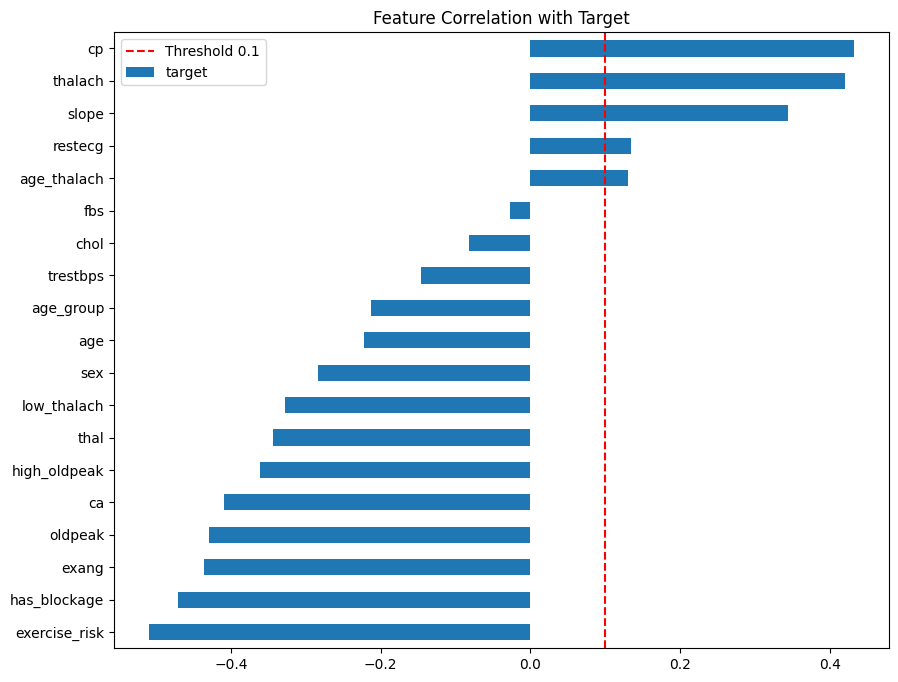

In [35]:
plt.figure(figsize=(10, 8))
corr_all = df_features.corr()['target'].drop('target')
corr_all.sort_values().plot(kind='barh')
plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold 0.1')
plt.title('Feature Correlation with Target')
plt.legend()
plt.show()

In [36]:
df_features = df_features.drop(columns=['chol', 'fbs', 'age_thalach'])

print("Final shape:", df_features.shape)

Final shape: (302, 17)


In [37]:
X=df_features.drop(columns=['target'])
y=df_features['target']

In [38]:
X.shape, y.shape

((302, 16), (302,))

In [39]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope', 'ca', 'thal', 'low_thalach', 'high_oldpeak',
       'age_group', 'has_blockage', 'exercise_risk'],
      dtype='object')

In [40]:
y.value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [41]:
continuous_features = ['age', 'trestbps', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal',
                        'low_thalach', 'high_oldpeak', 'age_group', 'has_blockage', 'exercise_risk']

In [42]:
print(f"Continuous: {continuous_features}")
print(f"Categorical: {categorical_features}")

Continuous: ['age', 'trestbps', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal', 'low_thalach', 'high_oldpeak', 'age_group', 'has_blockage', 'exercise_risk']


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X[continuous_features] = scaler.fit_transform(X[continuous_features])
X[continuous_features].head(2)

,age,trestbps,thalach,oldpeak
0,-0.267966,-0.376556,0.806035,-0.037124
1,-0.157260,0.478910,0.237495,1.773958


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,roc_auc_score, roc_curve 

In [46]:
models={
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42,n_estimators=100),
    'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(verbosity=0, eval_metric='logloss', random_state=42,)
}

In [47]:
##  Train & Evaluate All Models
results = {}

for name, model in models.items():
    # Cross validation
    cv_scores = cross_val_score(model, X_train, y_train, 
                                 cv=5, scoring='accuracy')
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cv_scores.mean()
    
    results[name] = {
        'model':   model,
        'y_pred':  y_pred,
        'y_prob':  y_prob,
        'accuracy': acc,
        'auc':      auc,
        'cv_score': cv
    }
    
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"  CV Accuracy : {cv:.3f} ± {cv_scores.std():.3f}")
    print(f"  Test Accuracy: {acc:.3f}")
    print(f"  AUC Score   : {auc:.3f}")

  Logistic Regression
  CV Accuracy : 0.851 ± 0.043
  Test Accuracy: 0.803
  AUC Score   : 0.885
  KNN
  CV Accuracy : 0.813 ± 0.037
  Test Accuracy: 0.787
  AUC Score   : 0.804
  Decision Tree
  CV Accuracy : 0.781 ± 0.056
  Test Accuracy: 0.738
  AUC Score   : 0.741
  Random Forest
  CV Accuracy : 0.813 ± 0.045
  Test Accuracy: 0.787
  AUC Score   : 0.846
  SVM
  CV Accuracy : 0.818 ± 0.033
  Test Accuracy: 0.770
  AUC Score   : 0.859
  XGBoost
  CV Accuracy : 0.788 ± 0.059
  Test Accuracy: 0.705
  AUC Score   : 0.848


In [48]:
summary = pd.DataFrame({
    name: {
        'CV Accuracy':   f"{v['cv_score']:.3f}",
        'Test Accuracy': f"{v['accuracy']:.3f}",
        'AUC Score':     f"{v['auc']:.3f}"
    }
    for name, v in results.items()
}).T

summary = summary.sort_values('AUC Score', ascending=False)
print("\n=== Model Comparison ===\n")
print(summary)


=== Model Comparison ===

                    CV Accuracy Test Accuracy AUC Score
Logistic Regression       0.851         0.803     0.885
SVM                       0.818         0.770     0.859
XGBoost                   0.788         0.705     0.848
Random Forest             0.813         0.787     0.846
KNN                       0.813         0.787     0.804
Decision Tree             0.781         0.738     0.741


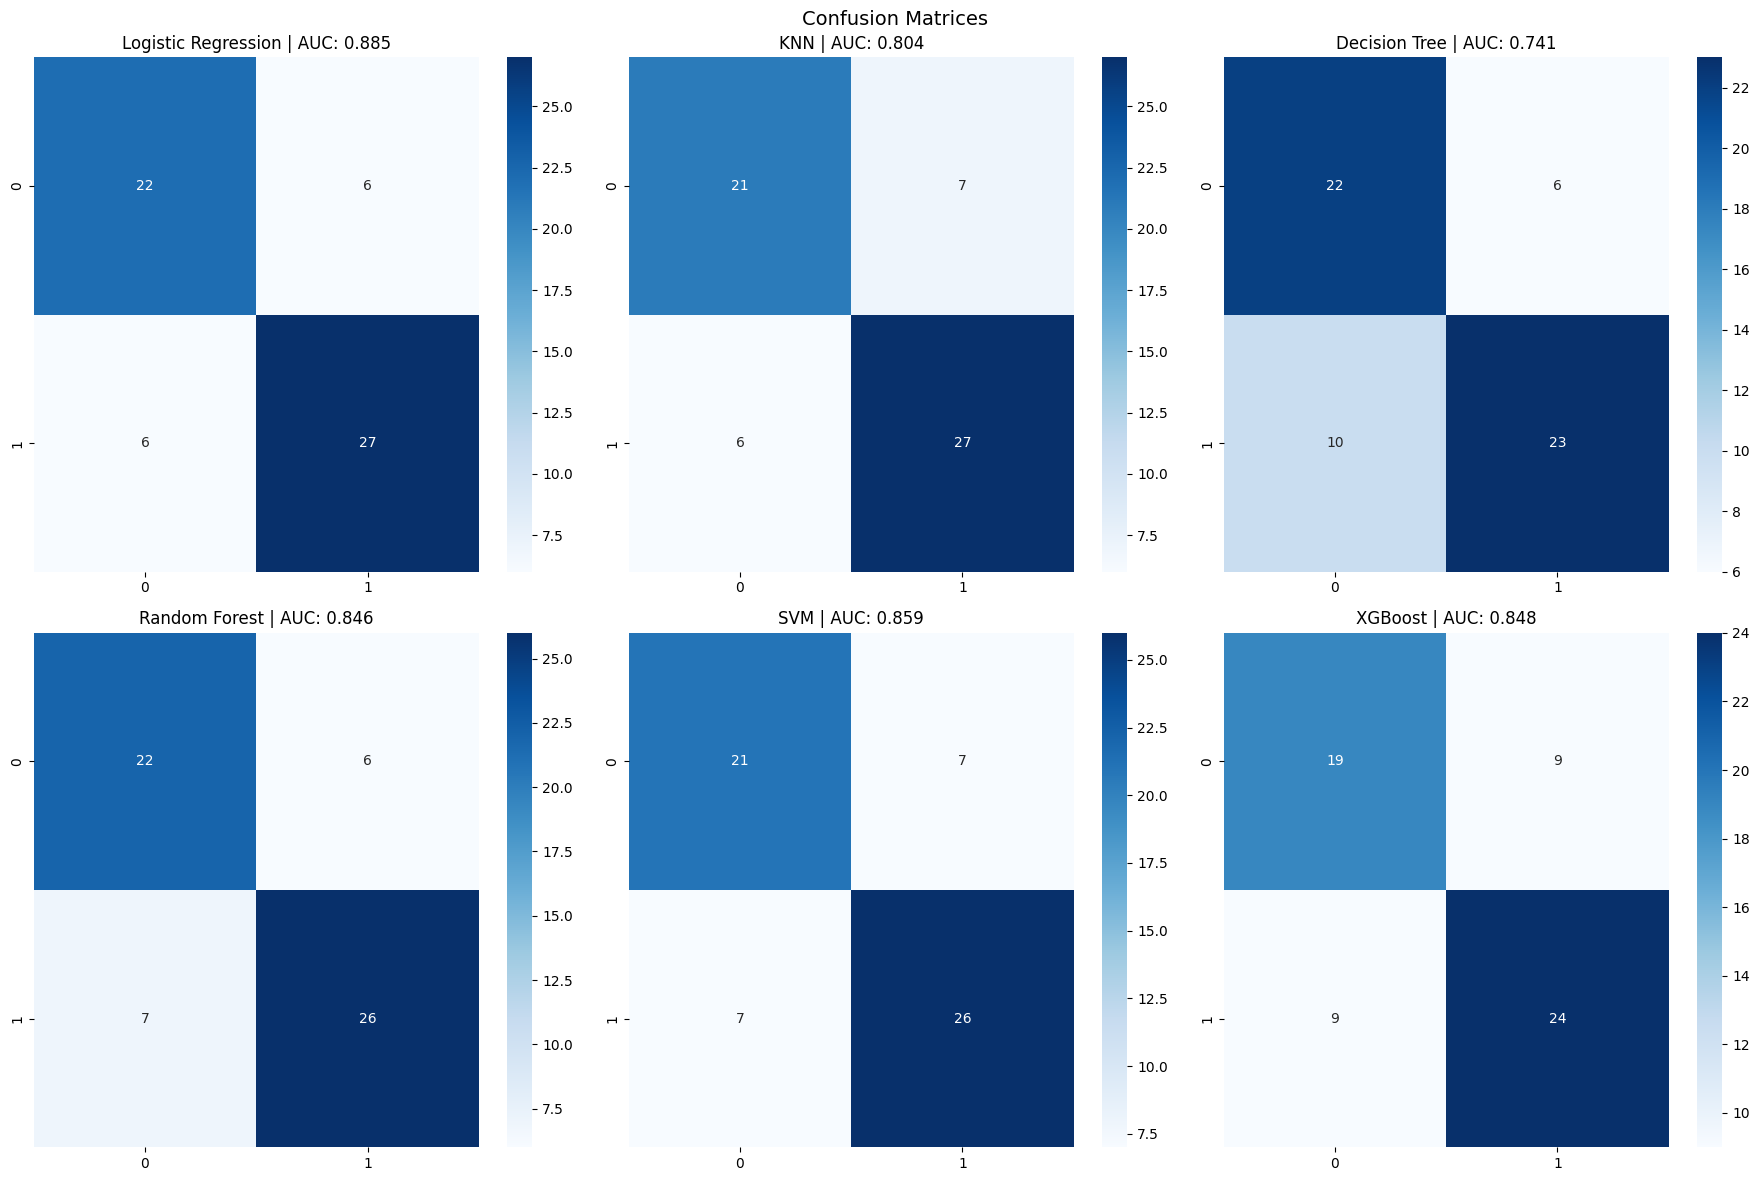

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, v) in enumerate(results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name} | AUC: {v["auc"]:.3f}')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
for name, v in results.items():
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, v['y_pred'],
                                target_names=['No Disease','Disease']))
    print()


  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        28
     Disease       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



  KNN
              precision    recall  f1-score   support

  No Disease       0.78      0.75      0.76        28
     Disease       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



  Decision Tree
              precision    recall  f1-score   support

  No Disease       0.69      0.79      0.73        28
     Disease       0.79      0.70      0.74        33

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74  

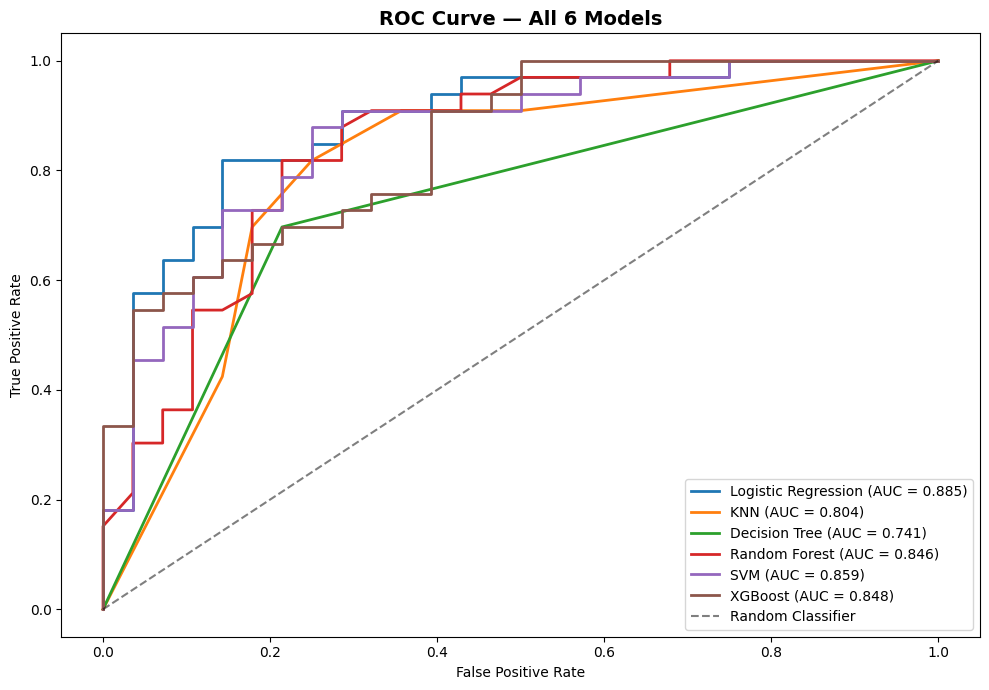

In [52]:
plt.figure(figsize=(10, 7))

for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {v['auc']:.3f})", linewidth=2)

plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All 6 Models', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [53]:
from sklearn.model_selection import GridSearchCV
def tune_model(model, params, X_train, y_train):
    grid = GridSearchCV(model, params, 
                        cv=5, 
                        scoring='roc_auc',
                        n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best params: {grid.best_params_}")
    print(f"Best AUC:    {grid.best_score_:.3f}")
    return grid.best_estimator_ 

In [54]:
 #1. Logistic Regression
print("=== Logistic Regression ===")
lr_best = tune_model(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    {'C': [0.01, 0.1, 1, 10, 100]},
    X_train, y_train)

# 2. KNN
print("\n=== KNN ===")
knn_best = tune_model(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 9, 11, 15],
     'weights': ['uniform', 'distance']},
    X_train, y_train)

# 3. Decision Tree
print("\n=== Decision Tree ===")
dt_best = tune_model(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    {'max_depth': [3, 5, 7, 10],
     'min_samples_split': [2, 5, 10]},
    X_train, y_train)

# 4. Random Forest
print("\n=== Random Forest ===")
rf_best = tune_model(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    {'n_estimators': [100, 200],
     'max_depth': [5, 10, None],
     'min_samples_split': [2, 5]},
    X_train, y_train)

# 5. XGBoost
print("\n=== XGBoost ===")
xgb_best = tune_model(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    {'n_estimators': [100, 200],
     'max_depth': [3, 5, 7],
     'learning_rate': [0.01, 0.1, 0.3]},
    X_train, y_train)

# 6. SVM
print("\n=== SVM ===")
svm_best = tune_model(
    SVC(class_weight='balanced', random_state=42, probability=True),
    {'C': [0.1, 1, 10],
     'kernel': ['rbf', 'linear'],
     'gamma': ['scale', 'auto']},
    X_train, y_train)

=== Logistic Regression ===
Best params: {'C': 1}
Best AUC:    0.921

=== KNN ===
Best params: {'n_neighbors': 15, 'weights': 'uniform'}
Best AUC:    0.889

=== Decision Tree ===
Best params: {'max_depth': 3, 'min_samples_split': 2}
Best AUC:    0.813

=== Random Forest ===
Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best AUC:    0.908

=== XGBoost ===
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best AUC:    0.896

=== SVM ===
Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best AUC:    0.911


In [55]:
tuned_models = {
    'Logistic Regression': lr_best,
    'KNN':                 knn_best,
    'Decision Tree':       dt_best,
    'Random Forest':       rf_best,
    'XGBoost':             xgb_best,
    'SVM':                 svm_best
}

tuned_results = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    tuned_results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_prob)
    }

# Compare before vs after
print(f"\n{'='*55}")
print(f"{'Model':<22} {'Before AUC':>12} {'After AUC':>12} {'Δ':>6}")
print(f"{'='*55}")
for name in results:
    before = results[name]['auc']
    after  = tuned_results[name]['auc']
    delta  = after - before
    symbol = '↑' if delta > 0 else '↓'
    print(f"{name:<22} {before:>12.3f} {after:>12.3f} {symbol}{abs(delta):.3f}")


Model                    Before AUC    After AUC      Δ
Logistic Regression           0.885        0.885 ↓0.000
KNN                           0.804        0.861 ↑0.057
Decision Tree                 0.741        0.846 ↑0.104
Random Forest                 0.846        0.870 ↑0.024
SVM                           0.859        0.885 ↑0.026
XGBoost                       0.848        0.839 ↓0.010


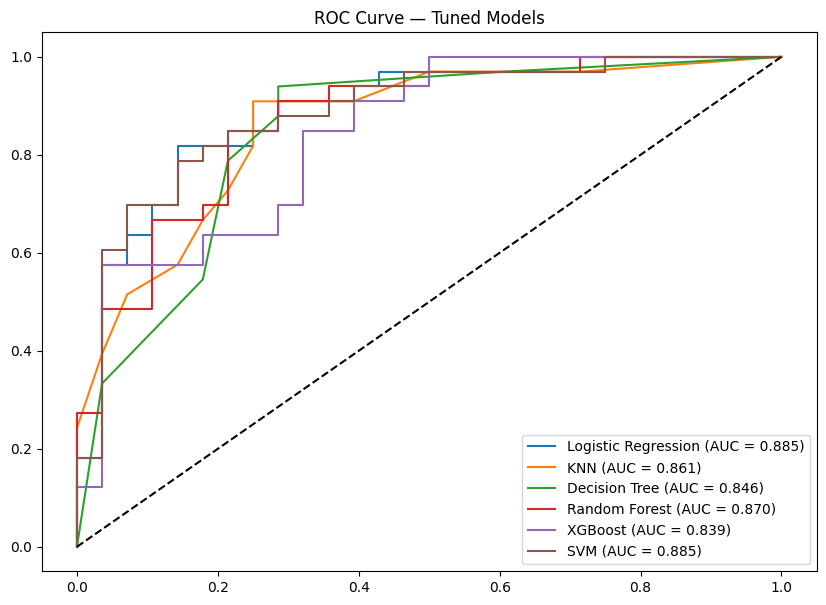

In [56]:
# ROC Curve - Tuned
plt.figure(figsize=(10, 7))

for name, v in tuned_results.items():
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {v['auc']:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve — Tuned Models')
plt.legend()
plt.show()

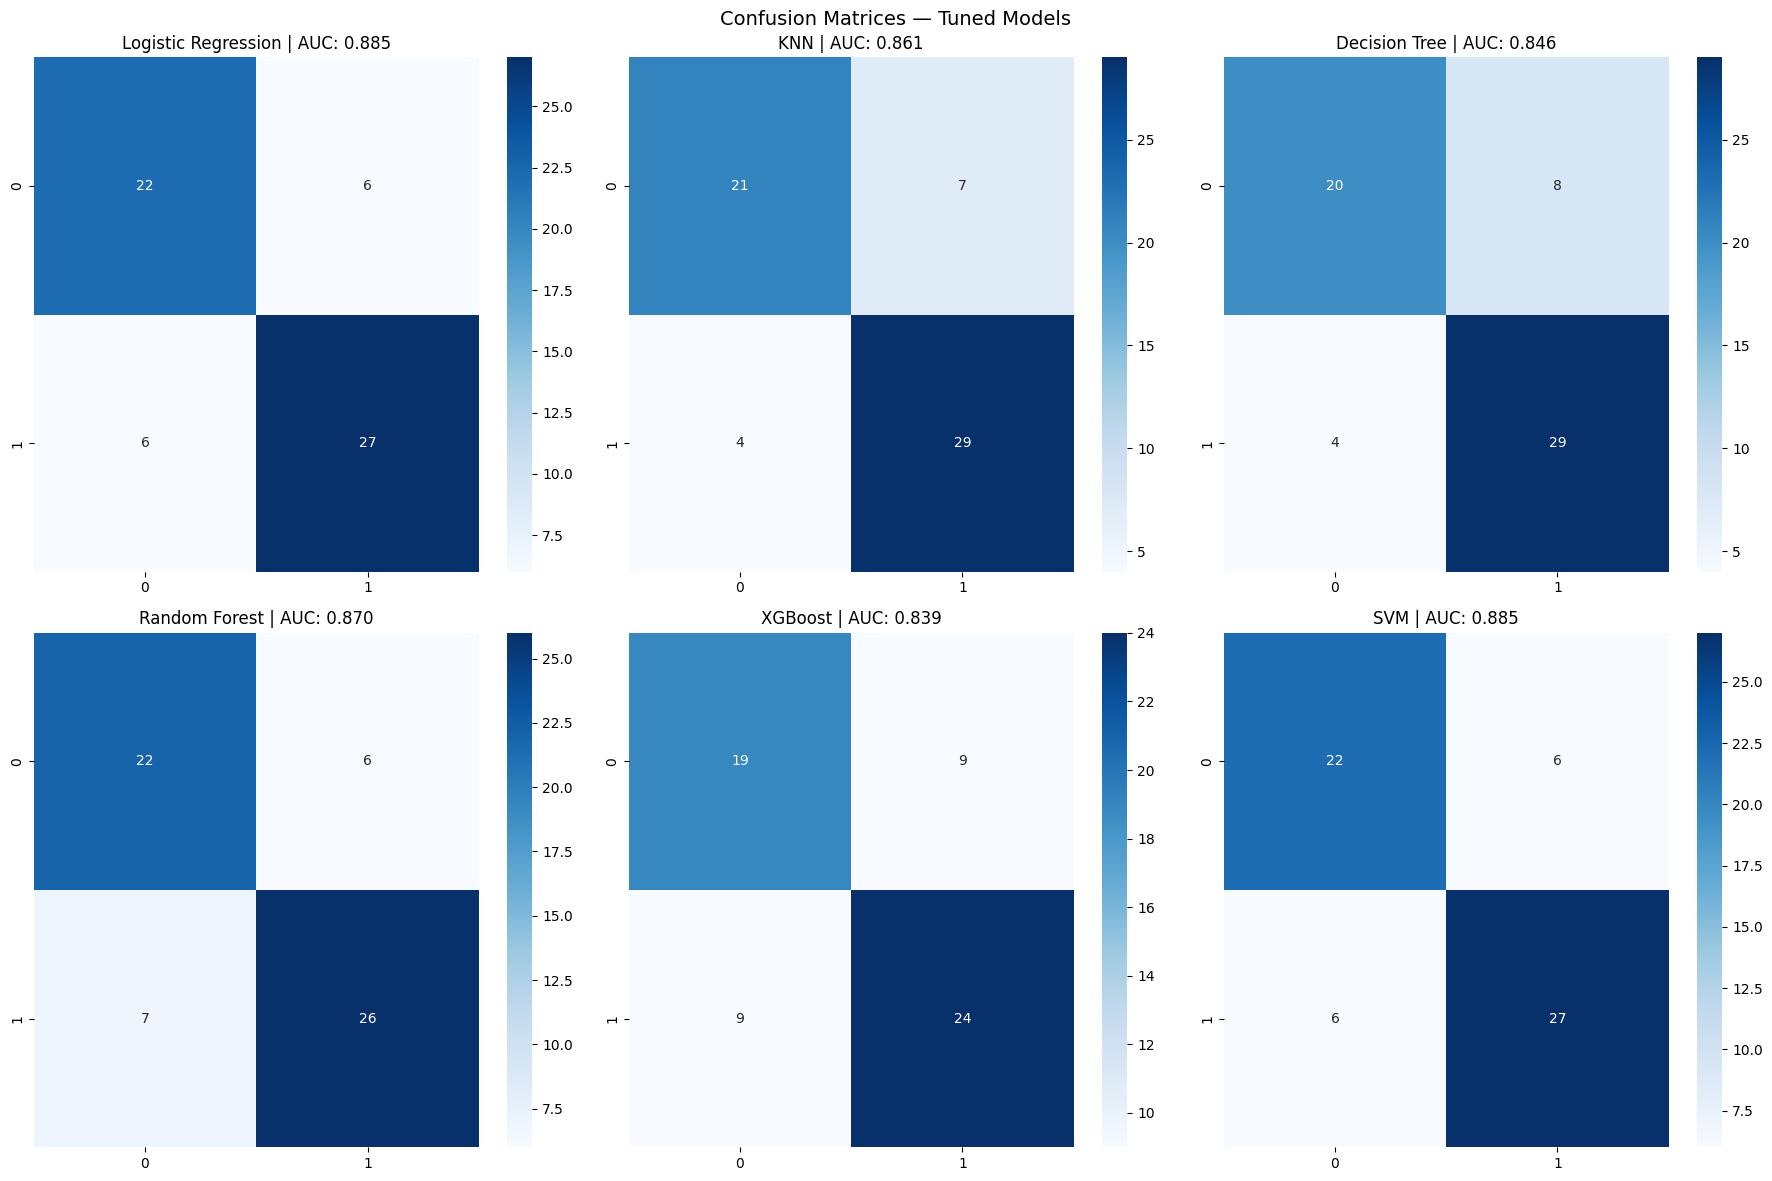

In [57]:
# Confusion Matrix - Tuned
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, v) in enumerate(tuned_results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name} | AUC: {v["auc"]:.3f}')

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=14)
plt.tight_layout()
plt.show()

In [60]:
import shap
# Use best model = Logistic Regression
best_model = tuned_results['Logistic Regression']['model']

# SHAP explainer
explainer = shap.LinearExplainer(best_model, X_train)
shap_values = explainer(X_test)

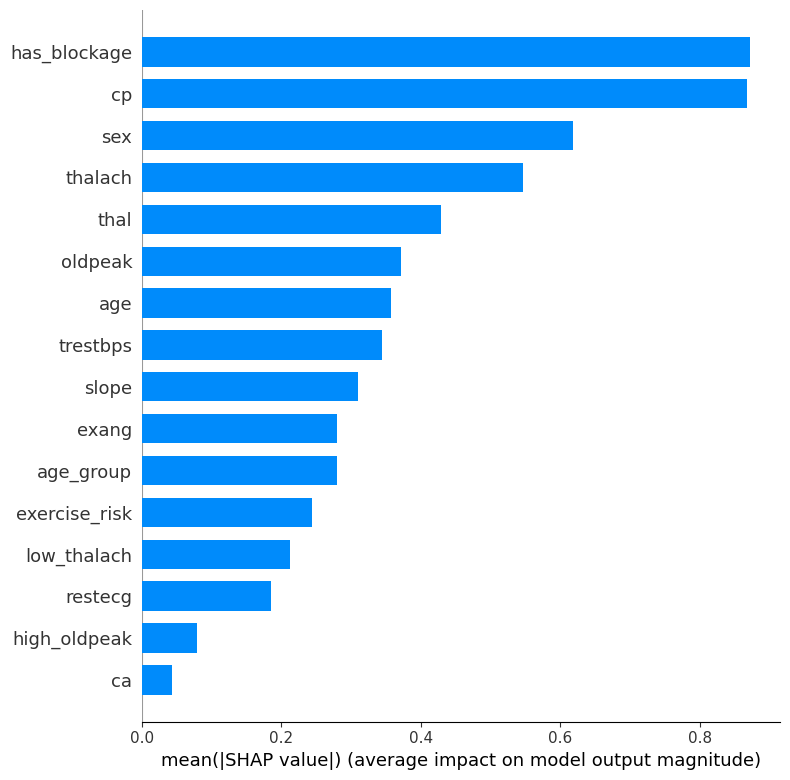

In [61]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  title='SHAP — Global Feature Importance')

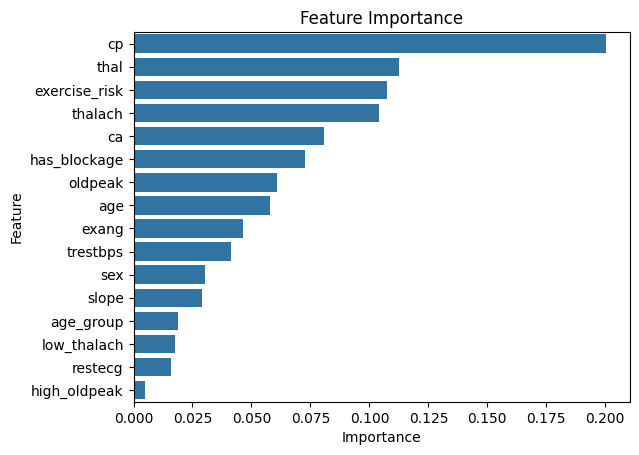

In [62]:
### feature importance for Random Forest
rf_model = tuned_results['Random Forest']['model']

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.show()

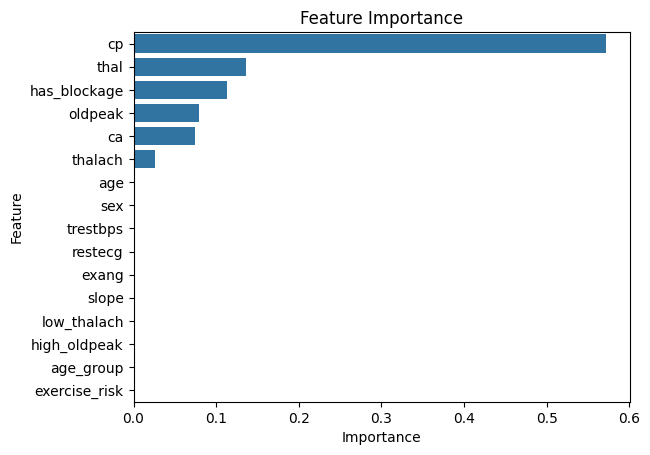

In [65]:
### feature importance for Random Forest
rf_model = tuned_results['Decision Tree']['model']

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.show()


Clinical Patterns Discovered¶
1. Chest Pain Type (cp) is the #1 signal
Patients with cp = 0 (asymptomatic) paradoxically showed the highest disease rate — silent heart disease is dangerous

2. Vessel Blockage is critical
has_blockage (ca > 0) became the #1 SHAP feature Any blocked vessel dramatically increases disease probability

3. Max Heart Rate matters more than Cholesterol
thalach (AUC correlation = 0.42) vs chol (0.08) Low max heart rate = poor cardiac response = high risk Cholesterol alone is not a reliable predictor here

4. Exercise stress is a combined signal
exercise_risk (exang + high_oldpeak) ranked #3 in importance Patients who experience angina AND ST depression during exercise are at significantly higher risk

5. Age pattern is non-linear
Risk increases sharply after age 55 But younger patients (40-55) with bad cp or ca are equally at risk → age alone is misleading


Model Verdict¶
Model	AUC	Verdict
Logistic Regression	0.885	Best overall
SVM	0.885	Tied best
Random Forest	0.870	Best ensemble
XGBoost	0.839	Underperformed
KNN	0.861	Improved after tuning
Decision Tree	0.846	Most improved (+0.104)
Logistic Regression outperforming XGBoost confirms that on small medical datasets, simpler models generalize better.




Limitations¶

Small dataset (302 patients) → results may not generalize
Dataset is from 1988 Cleveland clinic → may be outdated
XGBoost underperformed → needs more data to shine
Model should assist doctors, not replace them


Final Takeaway

"The best predictor of heart disease in this dataset is not cholesterol or age — it is chest pain type, vessel blockage, and how the heart responds under exercise stress. These three signals together define cardiac risk."